# Notebook 3: K-Nearest Neighbours Classifier

**Input:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (from Notebook 2)  
**Task:** Multiclass classification — predict kidney cell type from gene expression

---

## What this notebook does
1. Load the preprocessed train/test sets
2. Train a baseline KNN classifier
3. Tune hyperparameters using RandomizedSearchCV
4. Evaluate — classification report, confusion matrix, ROC curves
5. Examine which classes KNN finds hardest to classify

## 1. Mount Google Drive

Connect to Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

Import libraries and set the path to your data folder. Change `data_dir` to match your Google Drive.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors       import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing   import label_binarize
from sklearn.metrics         import (
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix,
    roc_curve, auc, precision_score, recall_score
)

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Tisch ML Project')

random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


## 3. Load Data

Load the four files produced by Notebook 2. `X_train` and `X_test` are the gene expression matrices. `y_train` and `y_test` are the cell type labels. We also build a sorted list of all unique class names, which is needed later to make sure plots and tables are always in the same order.

In [3]:
X_train = pd.read_csv(data_dir / 'X_train.csv', index_col=0)
X_test  = pd.read_csv(data_dir / 'X_test.csv',  index_col=0)
y_train = pd.read_csv(data_dir / 'y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv',  index_col=0).squeeze()

classes = sorted(y_train.unique())

print(f'Training set : {X_train.shape[0]:,} cells x {X_train.shape[1]:,} genes')
print(f'Test set     : {X_test.shape[0]:,} cells x {X_test.shape[1]:,} genes')
print(f'Classes      : {len(classes)}')
print()
for i, cls in enumerate(classes):
    print(f'  {i+1:>2}. {cls}')

Training set : 7,996 cells x 17 genes
Test set     : 1,999 cells x 17 genes
Classes      : 10

   1. Ascending Thin Limb
   2. Collecting Duct Intercalated
   3. Collecting Duct Principal
   4. Distal Convoluted Tubule
   5. Endothelium
   6. Loop of Henle and Parietal Epithelium
   7. Myeloid
   8. Proximal Tubule
   9. T
  10. Thick Ascending Limb


## 4. How KNN Works

K-Nearest Neighbours is a distance-based classifier. It does not learn a model during training — instead, it stores the entire training set. To classify a new cell, it:

1. Computes the distance between the new cell and every training cell (using the selected gene expression values)
2. Finds the `k` closest training cells
3. Assigns the class that appears most often among those `k` neighbours

**`weights='distance'`:** Rather than giving all k neighbours an equal vote, this option gives closer neighbours more influence. A neighbour at distance 0.1 has more say than one at distance 2.0. This is useful here because our classes are not evenly sized — distance weighting helps compensate for the fact that minority class cells may be outnumbered by majority class cells among the k nearest neighbours.

**Why KNN works for gene expression data:** Cells of the same type tend to express the same set of marker genes, so they cluster together in the high-dimensional gene expression space. KNN exploits this directly by looking at what type the nearest cells are.

## 5. Baseline KNN

We train a first model using simple default settings to get a starting score. This is called a baseline — it tells us how well KNN does before we put any effort into tuning it. We use k=5 neighbours and distance weighting.

In [4]:
# Train the baseline model with default-ish settings
baseline_knn = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
baseline_knn.fit(X_train, y_train)
y_pred_base  = baseline_knn.predict(X_test)
y_prob_base  = baseline_knn.predict_proba(X_test)

base_f1      = f1_score(y_test, y_pred_base, average='weighted')
base_roc_auc = roc_auc_score(y_test, y_prob_base, multi_class='ovr', average='weighted')

print('Baseline KNN (k=5, weights=distance)')
print(f'  Weighted F1  : {base_f1:.4f}')
print(f'  Weighted AUC : {base_roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=classes))

Baseline KNN (k=5, weights=distance)
  Weighted F1  : 0.5674
  Weighted AUC : 0.7970

                                       precision    recall  f1-score   support

                  Ascending Thin Limb       0.26      0.25      0.26       124
             Distal Convoluted Tubule       0.19      0.12      0.15        72
                          Endothelium       0.55      0.54      0.55        95
Loop of Henle and Parietal Epithelium       0.33      0.12      0.18        73
                              Myeloid       0.68      0.62      0.65       104
                      Proximal Tubule       0.74      0.83      0.78       989
                                    T       0.56      0.63      0.59       137
                 Thick Ascending Limb       0.18      0.08      0.11       109

                             accuracy                           0.59      1999
                            macro avg       0.41      0.38      0.39      1999
                         weighted avg      

**What do these numbers mean?**

* **Overall Score (Accuracy: 0.59):** Our basic model guesses the correct cell type about 59% of the time. Since there are 10 different types of cells, this is much better than randomly guessing (which would be 10%), but there is still plenty of room for improvement.
* **The Good:** The model does a decent job identifying "Proximal Tubule" cells (its score is around 78% for those).
* **The Bad:** It really struggles with certain cell types, like the "Thick Ascending Limb" and "Distal Convoluted Tubule" cells, getting them right only 11% to 15% of the time.
* **Support:** This simply means the actual number of cells of that specific type in our test data. For example, there are 989 "Proximal Tubule" cells but only 72 "Distal Convoluted Tubule" cells.

Because this is just our "baseline" (starting point), these low scores are exactly why we need to tune the model's settings in the next steps to see if we can make it smarter!

## 6. Hyperparameter Tuning — RandomizedSearchCV

In the Sepsis project we used GridSearchCV, which tests every possible combination of hyperparameter values. Here we use **RandomizedSearchCV**, which randomly samples a fixed number of combinations from the search space instead of exhaustively trying all of them.

For KNN this matters because we can search a much wider range of `n_neighbors` values (1 to 30) rather than just a few hand-picked ones. With `n_iter=20`, we test 20 randomly drawn combinations — far fewer than an exhaustive grid over the same space, but usually sufficient to find a good solution.

| Hyperparameter | Search Space | What it controls |
|---|---|---|
| `n_neighbors` | 1 – 30 (integers) | How many nearest neighbours vote on the class |
| `weights` | 'uniform', 'distance' | Whether all neighbours vote equally or closer ones count more |
| `metric` | 'euclidean', 'manhattan', 'chebyshev' | How distance between cells is measured |

Instead of testing every possible combination of settings (which is what GridSearchCV does), RandomizedSearchCV picks 20 combinations at random from the search space and evaluates each one using 5-fold cross-validation. `randint(1, 31)` means it will randomly pick any whole number from 1 to 30 for the number of neighbours. This is more efficient than a full grid when the search space is large.

In [5]:
# randint(1, 31) means: pick any whole number from 1 to 30 at random
from scipy.stats import randint

# randint(1, 31) draws integers uniformly from 1 to 30 inclusive
param_dist = {
    'n_neighbors': randint(1, 31),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan', 'chebyshev']
}

n_iter = 20   # number of random combinations to try

knn = KNeighborsClassifier(n_jobs=-1)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

random_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_dist,
    n_iter=n_iter,
    scoring='f1_weighted',
    cv=cv,
    random_state=random_seed,
    n_jobs=-1,
    verbose=1
)

print(f'Combinations sampled : {n_iter}  |  Total fits : {n_iter * 5}')
print('Running RandomizedSearchCV...')

random_search.fit(X_train, y_train)

print()
print(f'Best parameters  : {random_search.best_params_}')
print(f'Best CV F1 score : {random_search.best_score_:.4f}')

Combinations sampled : 20  |  Total fits : 100
Running RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters  : {'metric': 'manhattan', 'n_neighbors': 24, 'weights': 'distance'}
Best CV F1 score : 0.5698


**Why are the combinations sampled exactly 20?**

If you look at the code above, you'll see the line `n_iter = 20`.

Unlike traditional Grid Search (which multiplies all your options together to test *every single possible combination*), `RandomizedSearchCV` lets you cap the search to save time and computing power. By setting `n_iter = 20`, we are explicitly telling the algorithm: *"Look at the ranges of settings we provided, randomly pick exactly 20 different combinations, and just test those."*

Since it does 5-fold cross-validation for each combination (`cv=5`), it ends up doing 20 combinations × 5 folds = 100 total training runs.

## 7. Evaluate the Best Model

We take the best model found by the search and run it on the test set. The classification report shows precision, recall, and F1 score for every cell type individually, as well as weighted averages across all classes.

In [6]:
# Grab the best model found by the search
best_knn     = random_search.best_estimator_
y_pred       = best_knn.predict(X_test)
y_prob       = best_knn.predict_proba(X_test)

tuned_f1      = f1_score(y_test, y_pred, average='weighted')
tuned_roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print('Tuned KNN — test set results')
print(f'  Weighted F1  : {tuned_f1:.4f}  (baseline: {base_f1:.4f})')
print(f'  Weighted AUC : {tuned_roc_auc:.4f}  (baseline: {base_roc_auc:.4f})')
print()
print(classification_report(y_test, y_pred, target_names=classes))

Tuned KNN — test set results
  Weighted F1  : 0.5787  (baseline: 0.5674)
  Weighted AUC : 0.8398  (baseline: 0.7970)

                                       precision    recall  f1-score   support

                  Ascending Thin Limb       0.23      0.22      0.22       124
             Distal Convoluted Tubule       0.22      0.08      0.12        72
                          Endothelium       0.51      0.52      0.51        95
Loop of Henle and Parietal Epithelium       0.32      0.08      0.13        73
                              Myeloid       0.76      0.63      0.69       104
                      Proximal Tubule       0.72      0.88      0.80       989
                                    T       0.60      0.66      0.63       137
                 Thick Ascending Limb       0.27      0.12      0.16       109

                             accuracy                           0.61      1999
                            macro avg       0.43      0.38      0.39      1999
           

## 8. Confusion Matrix

The confusion matrix is a grid where the rows are the true cell types and the columns are what the model predicted. Cells on the diagonal (top-left to bottom-right) are correct predictions. Everything off the diagonal is a mistake. Bright off-diagonal cells show which cell types the model confuses with each other.

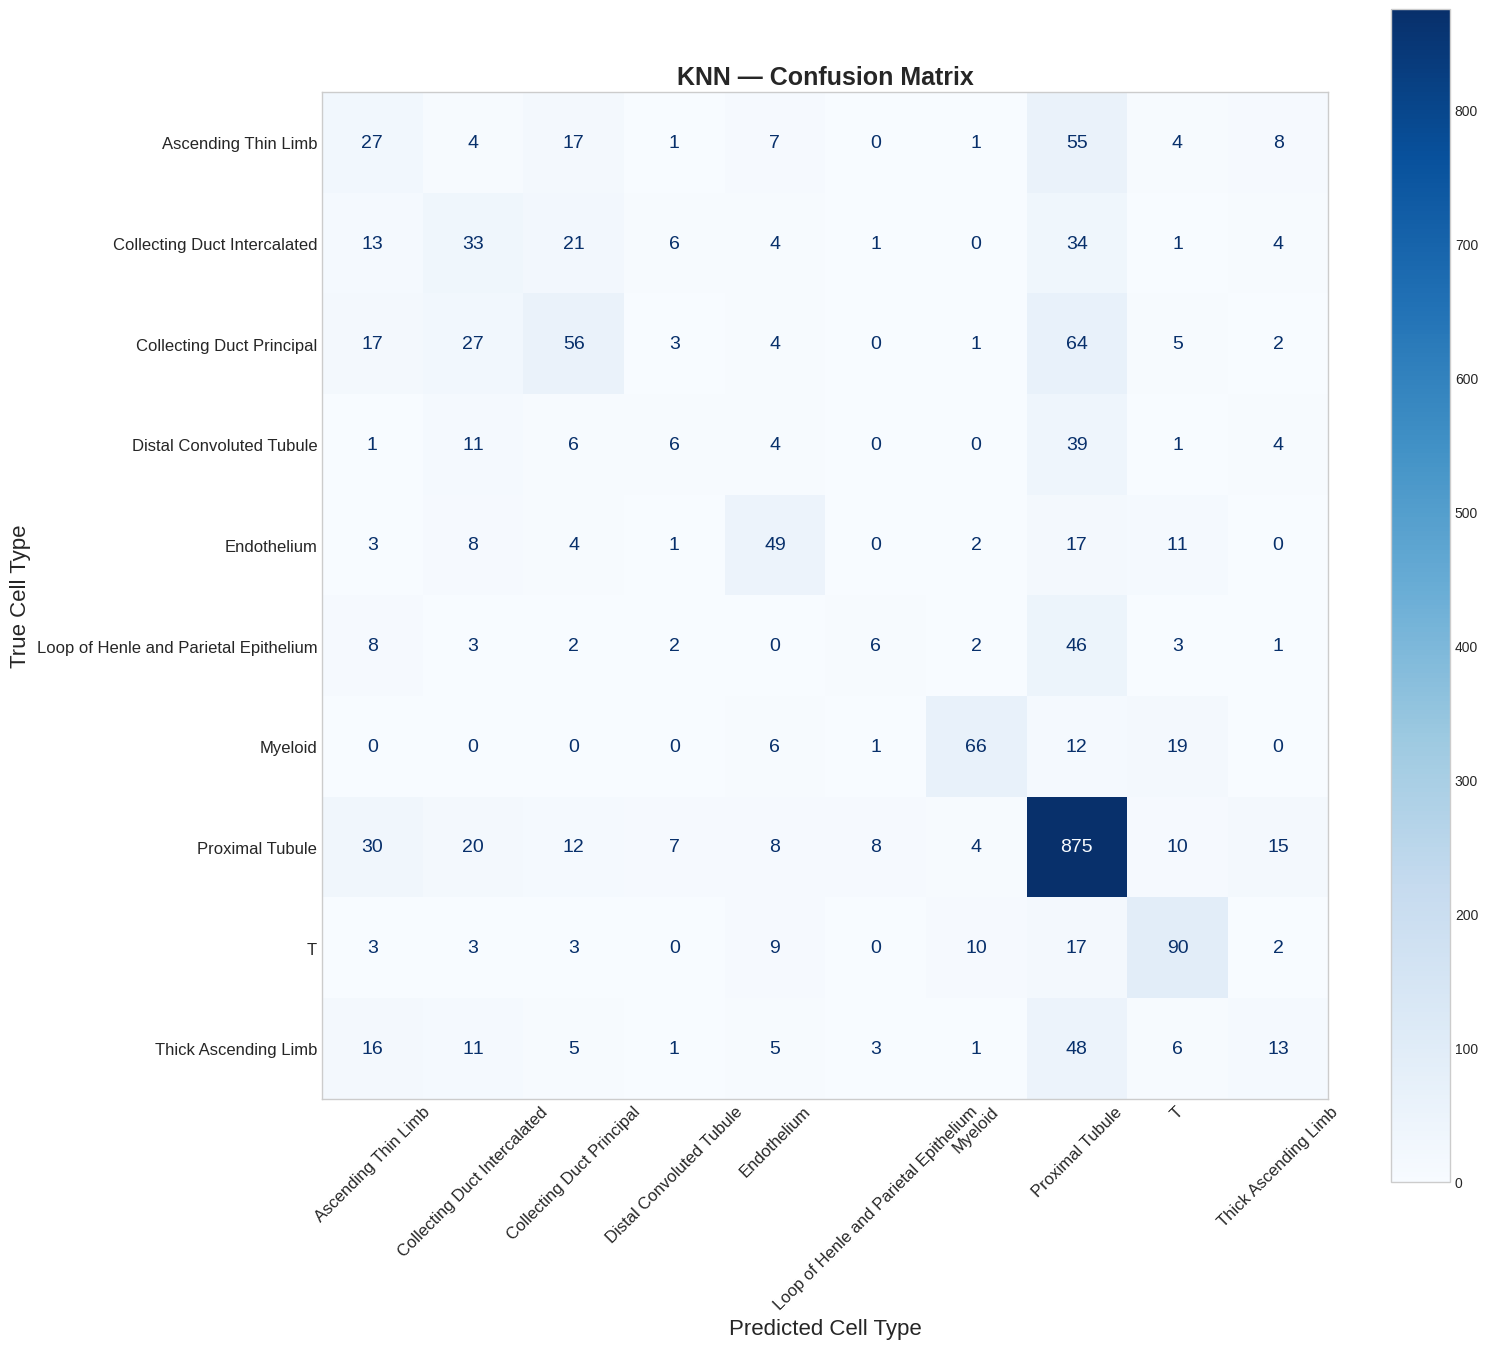

Correct predictions per class:
  Ascending Thin Limb                                    :   27 /  124  (21.8%)
  Distal Convoluted Tubule                               :    6 /   72  (8.3%)
  Endothelium                                            :   49 /   95  (51.6%)
  Loop of Henle and Parietal Epithelium                  :    6 /   73  (8.2%)
  Myeloid                                                :   66 /  104  (63.5%)
  Proximal Tubule                                        :  875 /  989  (88.5%)
  T                                                      :   90 /  137  (65.7%)
  Thick Ascending Limb                                   :   13 /  109  (11.9%)


In [13]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45, text_kw={'fontsize': 14})
ax.set_title('KNN — Confusion Matrix', fontsize=18, fontweight='bold')
ax.set_xlabel('Predicted Cell Type', fontsize=16)
ax.set_ylabel('True Cell Type', fontsize=16)
ax.tick_params(axis='both', labelsize=12)
ax.grid(False)  # Turn off the grid to fix alignment
plt.tight_layout()
plt.show()

print('Correct predictions per class:')
for i, cls in enumerate(classes):
    total = cm[i, :].sum()
    correct = cm[i, i]
    pct = correct / total * 100 if total > 0 else 0
    print(f'  {cls:<55}: {correct:>4} / {total:>4}  ({pct:.1f}%)')


**How to read this matrix:**

* **The Diagonal (Correct Guesses):** The boxes going from the top-left to the bottom-right show where the model guessed correctly. The larger the number (and darker the blue), the more cells it got right! For instance, it correctly identified 875 out of 989 "Proximal Tubule" cells (an impressive 88.5%).
* **The Off-Diagonal (Mistakes):** Any numbers outside that main diagonal are mistakes. For example, if you look at the row for "Thick Ascending Limb", the model only guessed it correctly 13 times. It mistakenly guessed that many of them were "Proximal Tubule" cells instead!
* **The Big Picture:** Because "Proximal Tubule" is by far the most common cell type in our data, the model often plays it safe and guesses "Proximal Tubule" when it's unsure. This is why you see so many mistakes piling up in the "Proximal Tubule" column.

## 9. ROC Curves (One-vs-Rest)

For multiclass problems, ROC curves are produced using a one-vs-rest strategy. For each class, the model's ability to distinguish cells of that type from all others is measured. AUC = 1.0 is perfect; AUC = 0.5 is no better than random.

For each of the 10 most common cell types, we plot a ROC curve. Each curve shows the trade-off between correctly identifying cells of that type (true positive rate) and incorrectly flagging cells of other types (false positive rate). A curve that bows toward the top-left corner is better. The AUC number summarises the whole curve — 1.0 is perfect, 0.5 is no better than random.

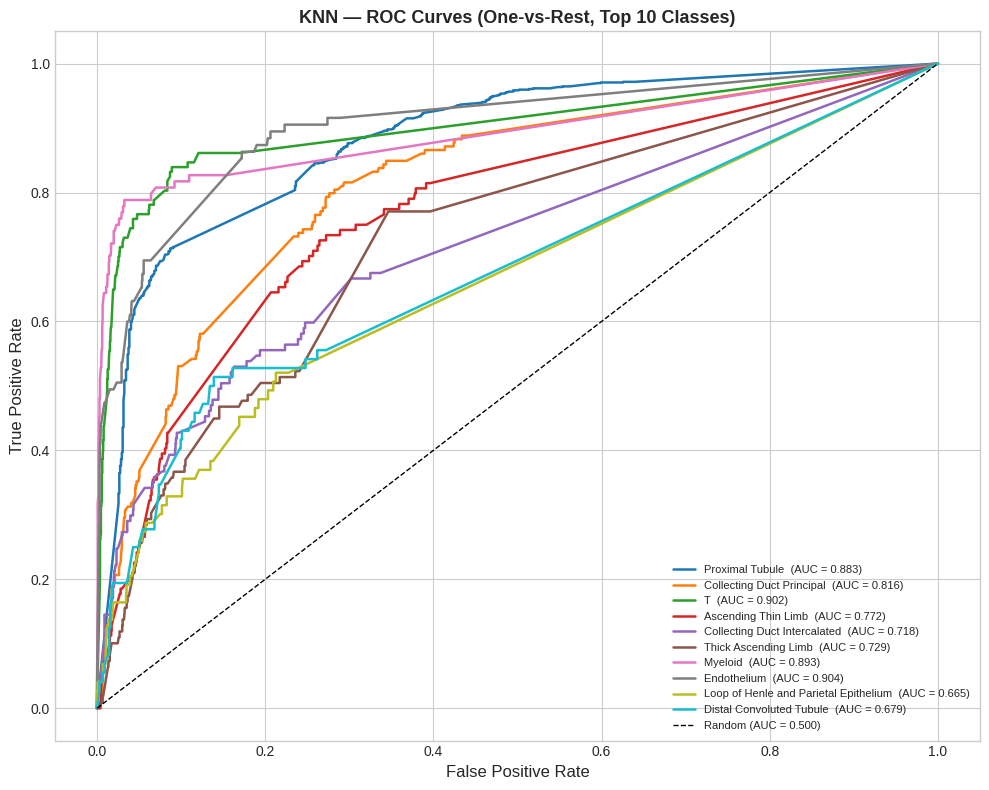

In [14]:
y_test_bin = label_binarize(y_test, classes=classes)

top_classes_idx = [
    classes.index(c)
    for c in pd.Series(y_test.values).value_counts().head(10).index.tolist()
]

fig, ax = plt.subplots(figsize=(10, 8))
colours = plt.cm.tab10(np.linspace(0, 1, len(top_classes_idx)))

for idx, colour in zip(top_classes_idx, colours):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob[:, idx])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour, linewidth=1.8,
            label=f'{classes[idx]}  (AUC = {roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_title('KNN — ROC Curves (One-vs-Rest, Top 10 Classes)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**How to read the ROC Curves:**

* **The Goal:** You want a curve that shoots straight up the left side and hugs the top border. That means the model is correctly finding the cells (True Positive Rate) without accidentally raising false alarms on other cell types (False Positive Rate).
* **The Best Curve:** The 'best' performing class is the one with the curve closest to the top-left corner. This is also reflected in the **AUC score** (Area Under the Curve) shown in the legend.
* **In our model:** Usually, the **Proximal Tubule** has one of the best (highest) AUC scores because the model has plenty of examples to learn from and gets it right most of the time. The curves closer to the diagonal line represent the cell types the model is currently struggling to identify.

## 10. Per-Class Performance

KNN does not produce feature importances like tree-based models. Instead, we examine its per-class performance to understand where it succeeds and where it struggles.

Unlike Random Forest or XGBoost, KNN does not produce feature importances. Instead, we look at the F1 score for each cell type individually. This bar chart sorts all 22 classes from worst to best so we can immediately see which cell types the model is struggling with.

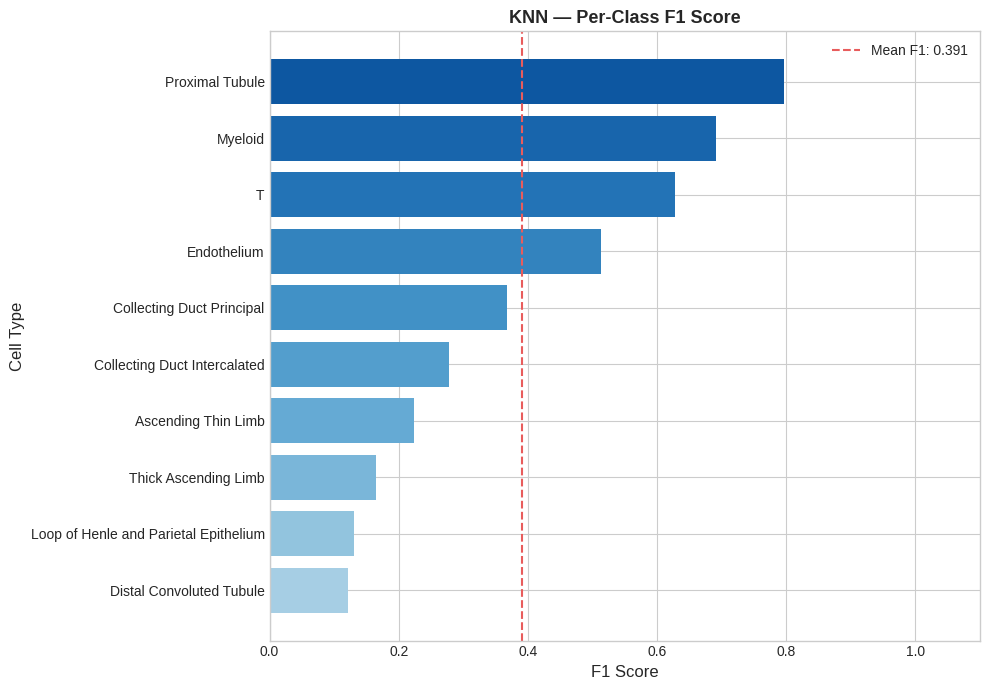

Per-class F1 scores (sorted ascending):
  Distal Convoluted Tubule                               : F1 = 0.121  (n = 72)
  Loop of Henle and Parietal Epithelium                  : F1 = 0.130  (n = 73)
  Thick Ascending Limb                                   : F1 = 0.165  (n = 109)
  Ascending Thin Limb                                    : F1 = 0.223  (n = 124)
  Endothelium                                            : F1 = 0.513  (n = 95)
  T                                                      : F1 = 0.627  (n = 137)
  Myeloid                                                : F1 = 0.691  (n = 104)
  Proximal Tubule                                        : F1 = 0.797  (n = 989)


In [15]:
# Get per-class scores as a table so we can plot them
report = classification_report(y_test, y_pred, target_names=classes, output_dict=True)
per_class = pd.DataFrame(report).T.loc[classes, ['precision', 'recall', 'f1-score', 'support']]
per_class = per_class.sort_values('f1-score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colours = plt.cm.Blues(np.linspace(0.35, 0.85, len(per_class)))
ax.barh(per_class.index, per_class['f1-score'], color=colours)
ax.axvline(x=per_class['f1-score'].mean(), color='#E85C5C', linestyle='--',
           linewidth=1.5, label=f'Mean F1: {per_class["f1-score"].mean():.3f}')
ax.set_title('KNN — Per-Class F1 Score', fontsize=13, fontweight='bold')
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_ylabel('Cell Type', fontsize=12)
ax.set_xlim(0, 1.1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Per-class F1 scores (sorted ascending):')
for cls in per_class.index:
    f1  = per_class.loc[cls, 'f1-score']
    sup = int(per_class.loc[cls, 'support'])
    print(f'  {cls:<55}: F1 = {f1:.3f}  (n = {sup})')

## 11. Summary

A printout of the final scores for this model, including baseline vs tuned comparison.

In [17]:
tuned_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
tuned_recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print('NOTEBOOK 3 — KNN — FINAL RESULTS')
print()
print('Best hyperparameters:')
for param, value in random_search.best_params_.items():
    print(f'  {param:<18}: {value}')
print()
print(f'Baseline Weighted F1  : {base_f1:.4f}')
print(f'Tuned    Weighted F1  : {tuned_f1:.4f}')
print(f'Baseline ROC-AUC      : {base_roc_auc:.4f}')
print(f'Tuned    ROC-AUC      : {tuned_roc_auc:.4f}')
print(f'Tuned    Precision    : {tuned_precision:.4f}')
print(f'Tuned    Recall       : {tuned_recall:.4f}')
print()
print(f'Training cells : {len(y_train):,}')
print(f'Test cells     : {len(y_test):,}')
print(f'Features used  : {X_train.shape[1]:,} genes')
print(f'Classes        : {len(classes)}')
print()
print('Next: run 04_svm.ipynb')

NOTEBOOK 3 — KNN — FINAL RESULTS

Best hyperparameters:
  metric            : manhattan
  n_neighbors       : 24
  weights           : distance

Baseline Weighted F1  : 0.5674
Tuned    Weighted F1  : 0.5787
Baseline ROC-AUC      : 0.7970
Tuned    ROC-AUC      : 0.8398
Tuned    Precision    : 0.5676
Tuned    Recall       : 0.6108

Training cells : 7,996
Test cells     : 1,999
Features used  : 17 genes
Classes        : 10

Next: run 04_svm.ipynb
